# A web app that asks a pool of model workers

A Django view takes an uploaded image and needs a model's answer. The model is a PyTorch network: tens of milliseconds to seconds per image and hundreds of megabytes once loaded, so the web processes must not each load it. The model runs in worker processes of its own, on other machines once it grows, and the web app asks them. That raises the questions this walkthrough answers by triggering each one on purpose: which worker gets a request, what happens to a request whose worker dies, how a new version of the workers goes out without a failed request, and what happens when the thing in the middle dies.

The thing in the middle is the multiplexer. Every web process holds one connection to each multiplexer and so does every worker; a request goes from a web process through a multiplexer to a worker, and the reply comes back the same way. A multiplexer holds no state beyond its connections, so losing one loses nothing that was not in flight, and a request that was in flight is sent again by its client; an event it held is lost.

![Web processes, multiplexers, model workers](diagrams/architecture.svg)

Everything runs on this machine, from the directory this notebook is in, which is also the finished example ([README.md](README.md)). The cells are the shell commands a reader would type, plus the Python that ships in the example's files, shown where it matters. Run it from the top: the first two cells stop whatever an earlier run left. A shell cell stops at the first command that fails, so a step that did not work shows as an error rather than as output that looks fine.

## 0. A clean slate

Every cell below that starts a process sends its output to a `.log` file and its process id to a `.pid` file, so that a cell can be run again and the last cell can stop everything. The first cell puts this kernel's Python first on the `PATH`, so that `python`, `pip` and `mxcontrol` in the shell cells are the ones of the environment the notebook runs on, and sets `MX_LOG_VERBOSITY` so that the library's chattier debug lines stay out of the logs we will read; its notices about connections, lost and made again, stay in. The second stops whatever a previous run left.

In [1]:
import os
import sys

os.environ["PATH"] = os.path.dirname(sys.executable) + os.pathsep + os.environ["PATH"]
os.environ["MX_LOG_VERBOSITY"] = "DEBUG:LOW"


def show(path, start, end=None):
    """Prints `path` from the line containing `start` up to the line containing `end`: the part worth reading."""
    lines = open(path).read().splitlines()
    first = next(index for index, line in enumerate(lines) if start in line)
    last = len(lines)
    if end:
        last = next(index for index, line in enumerate(lines) if end in line and index > first)
    print("\n".join(lines[first:last]).rstrip())

In [2]:
%%bash
for pid in *.pid; do [ -f "$pid" ] && kill "$(cat "$pid")" 2> /dev/null; done
rm -f *.pid *.log *.peers *.drain

## 1. Install

The library comes from PyPI as `mx-multiplexer`. The example's [requirements.txt](requirements.txt) adds Django, Pillow and a CPU build of torch, a 200 MB download rather than the 2 GB of the CUDA build, and [requirements-notebook.txt](requirements-notebook.txt) adds torchvision for the training step. The package brings the multiplexer with it: `mxcontrol`, on the `PATH` of the environment it is installed into. A release's static binary, its Debian package and its container image are the other ways ([docs/packaging.md](../../docs/packaging.md)). The shell cells call the web app with `curl`, which a minimal image such as `python:3.13-slim` does not have.

In [3]:
%pip install -q -r requirements-notebook.txt

Note: you may need to restart the kernel to use updated packages.


The rules file, next, starts with the system rules, which `mxcontrol generate_rules` writes, and then names the example's peer types and message types. `mxcontrol generate_constants` writes them as a Python module, so that the code says `peers.INFERENCE` rather than `202`. The example commits the result; running it again is how you would start from a rules file of your own.

In [4]:
%%bash
set -euo pipefail
mxcontrol generate_constants inference.rules --python multiplexer_constants.py --pyi multiplexer_constants.pyi

multiplexer_constants.py
multiplexer_constants.pyi


## 2. The rules file

[inference.rules](inference.rules) is what every multiplexer reads at start: the peer types it will see, the message types, and where each message type goes. It opens with the system rules every rules file starts from, the protocol's own types 1 to 99 and the six the libraries and `mxcontrol` use by name ([docs/rules.md](../../docs/rules.md)), which `mxcontrol generate_rules inference.rules` wrote; the example's part follows them:

In [5]:
%%bash
set -euo pipefail
sed -n '/^# The example/,$p' inference.rules

# The example's peers and messages.

peer {
    type: 201
    name: "WEB"
    comment: "the web app'

s processes, and the command-line client: they ask"
}

peer {
    type: 202
    name: "INFERENCE"
  

  comment: "a model worker: answers INFER_REQUEST; run as many as you like"
}

type {
    type: 301


    name: "INFER_REQUEST"
    comment: "an image to classify, payload InferRequest; one worker answe

rs with INFER_RESPONSE"
    to {
        peer: "INFERENCE"
        whom: ANY
    }
}

type {
    typ

e: 302
    name: "INFER_RESPONSE"
    comment: "the label and the probabilities, payload InferRespon

se"
}


Two peer types: `WEB` for whoever asks, the web app's processes and the command-line client, and `INFERENCE` for the workers. Two message types: `INFER_REQUEST`, whose `to` block says it goes to any one `INFERENCE` peer, and `INFER_RESPONSE`, with no `to` block because a reply is addressed to the peer that asked. Which worker gets a request is the multiplexer's choice, round robin over the ones connected to it.

Both payloads are protocol buffers in [inference.proto](inference.proto), an image in, a label and the probabilities out, compiled once with `protoc --python_out=. --pyi_out=. inference.proto` into the committed `inference_pb2.py`.

## 3. Train the model

A small convolutional network that reads a handwritten digit off a 28 by 28 grey image, trained on MNIST for one epoch: a few seconds on a CPU, about 97% on the test set. [train.py](train.py) downloads the dataset into `data/` (12 MB), trains, writes `weights.pt`, and writes one sample image per digit into `samples/` for the client to send. The weights and the samples are committed, so nobody else has to run this cell, and nothing about the multiplexer depends on it.

In [6]:
%%bash
set -euo pipefail
python train.py

epoch 1 step    0 loss 2.323
epoch 1 step  300 loss 0.145
epoch 1 step  600 loss 0.124
epoch 1 step  900 loss 0.054
epoch 1 done in 3 s, test accuracy 0.9735
weights saved to …/examples/inference/weights.pt, 39317 bytes
samples written to …/examples/inference/samples


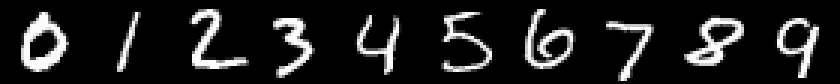

In [7]:
from IPython.display import display
from PIL import Image

strip = Image.new("L", (10 * 28, 28))
for digit in range(10):
    strip.paste(Image.open(f"samples/{digit}.png"), (digit * 28, 0))
display(strip.resize((10 * 28 * 3, 28 * 3), Image.NEAREST))

[model.py](model.py) is the part that matters to the example: `load()` runs once when a worker starts, `predict()` once per request, and nothing else knows what the model is. For a real model these two change and the rest stays.

In [8]:
show("model.py", "def load(", "def to_tensor(")
show("model.py", "def predict(")

def load(path: str = WEIGHTS, device: str = "cpu") -> DigitNet:
    """The trained model, in evaluation mode, on `device`."""
    model = DigitNet()
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()
def predict(model: DigitNet, image_bytes: bytes) -> tuple[int, list[float]]:
    """The digit the model reads in the image, and the probability of each digit."""
    device = next(model.parameters()).device  # the model's, a GPU's when train.py loaded it there
    with torch.no_grad():
        probabilities = torch.softmax(model(to_tensor(image_bytes).to(device)), dim=1)[0]
    return int(probabilities.argmax()), [float(p) for p in probabilities]


## 4. The worker

A worker is a backend: a process that connects to every multiplexer as a peer of type `INFERENCE` and answers what the multiplexers route to it. The library's two server classes do that for you, and how long a request takes decides between them.

`BaseMultiplexerServer` is the plain one: it runs the connection and `handle_message()` on the same thread, so while the handler runs nothing else happens, including the heartbeats the multiplexer expects. A multiplexer drops a peer that has been silent for long enough, 90 seconds with the defaults ([docs/semantics.md](../../docs/semantics.md)), so a single call to the handler that takes longer than that gets the backend dropped mid-work; requests queued behind one another do not, since the loop heartbeats between them, and a queue costs its callers time with either class. `BaseThreadedMultiplexerServer` runs the connection on an io thread that heartbeats, answers the multiplexer and takes messages, and hands each request to a worker thread that runs `handle_message()`: the peer stays registered under a request of any length, and `--workers` handles several at once on one loaded model. That is the one for a model, and [backend.py](backend.py) uses it: the model is loaded once in the constructor, and the handler parses the request, runs the model and replies.

In [9]:
show("backend.py", "class Classifier", "def parse_addresses")

class Classifier(BaseThreadedMultiplexerServer):
    """Answers INFER_REQUEST; everything else is dropped."""

    multiplexer_client_type = peers.INFERENCE

    def __init__(
        self,
        addresses: list[tuple[str, int]],
        weights: str = WEIGHTS,
        name: str | None = None,
        slow: float = 0.0,
        drain_file: str | None = None,
        workers: int = 1,
    ) -> None:
        # The model first: loading is the slow part and the one that can
        # fail. The order is free otherwise: the base class connects and
        # handles only in serve_forever().
        self.model: DigitNet = load(weights)
        self.name = name or f"{socket.gethostname()}:{os.getpid()}"
        self.slow = slow
        self.drain_file = drain_file
        self.asked_to_leave = False  # set by the SIGTERM handler, read by periodic_task()
        self.answered = 0
        super().__init__(addresses, workers=workers)

    def handle_message(self, request: Request) -> None:
     

The order in the constructor is a choice, not a rule: the base class connects and handles only in `serve_forever()`, so nothing reaches the handler before `__init__` is done; the model loads first only so that a missing weights file fails at once. Two more things in it. `--slow` adds a sleep to every request, so that the walkthrough can show what a slow model does to the system without waiting for one; a real model is simply slow. And `periodic_task()`, which the base class calls between polls on the serving thread, watches for a file: creating the file asks the worker to leave the way a rolling restart wants, which step 9 uses; SIGTERM does the same, for an orchestrator, through a flag its handler sets and `periodic_task()` reads, since a handler may interrupt the library and must call none of it ([docs/api_python.md](../../docs/api_python.md) says why). `--workers` is how many requests one process handles at once; one is right for a model that holds the CPU, and step 11 says when it is not.

## 5. First request: one multiplexer, one worker

A multiplexer is one command. `--peers-file` makes it write who is connected, on every change, which is the easiest way to watch it.

In [10]:
%%bash
set -euo pipefail
mxcontrol run_multiplexer --rules inference.rules --address 127.0.0.1:1980 --peers-file mx1.peers > mx1.log 2>&1 &
echo $! > mx1.pid
while ! grep -q "starting MX server" mx1.log && kill -0 $(cat mx1.pid); do sleep 0.1; done
kill -0 $(cat mx1.pid)  # still running
cat mx1.log

[INFO]  ts=…  pid=361338  ctx=demo.mxcontrol.run_multiplexer.multiplexer.server  flw=""  tx

t="rules loaded from inference.rules: 0a53f35b, 19 message types, 7 peer types"  from=multiplexer/se

rver.cc:618
[INFO]  ts=…  pid=361338  ctx=demo.mxcontrol.run_multiplexer  flw=""  txt="star

ting MX server on 127.0.0.1:1980"  from=mxcontrol/start_multiplexer_server.cc:128


A worker: the multiplexer's address, and a name it signs its answers with. It prints `ready` once it is connected, and the multiplexer's peers file lists it. (The loop waits for that line, or for the process to be gone.)

In [11]:
%%bash
set -euo pipefail
python backend.py 127.0.0.1:1980 --name alpha > alpha.log 2>&1 &
echo $! > alpha.pid
while ! grep -q '^ready' alpha.log && kill -0 $(cat alpha.pid); do sleep 0.1; done
kill -0 $(cat alpha.pid)
cat alpha.log
echo; cat mx1.peers

[INFO]  ts=…  pid=361346  ctx=demo.python.ConnectionsManager  flw=""  txt="registered conne

ction id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:141
re

ady: worker alpha, instance 5939994110512505245



5939994110512505245 INFERENCE 202


The client. [client.py](client.py) is the command-line version of what the web app will do: a `ThreadedClient` of type `WEB` connected to every multiplexer, and one `query()` per image with the answer parsed:

In [12]:
show("client.py", "def classify(", "def main(")

def classify(client: ThreadedClient, image: bytes, timeout: float = 10.0) -> InferResponse:
    """One request, its answer parsed; raises what query() raises."""
    reply = client.query(InferRequest(image=image), type=types.INFER_REQUEST, timeout=timeout)
    response = InferResponse()
    response.ParseFromString(reply.message)
    return response


In [13]:
%%bash
set -euo pipefail
python client.py 127.0.0.1:1980 samples/7.png

[INFO]  ts=…  pid=361416  ctx=demo.python.ConnectionsManager  flw=""  txt="registered conne

ction id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:141


samples/7.png: 7  p=1.000  worker=alpha  model 6.6 ms  round trip 7.3 ms


[INFO]  ts=…  pid=361416  ctx=demo.python.ConnectionsManager  flw=""  txt="unregistered con

nection id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:218


What happened, in the terms of [docs/query.md](../../docs/query.md): the client sent the request through its one connection; the multiplexer found the rule for `INFER_REQUEST`, picked a worker of type `INFERENCE` round robin, one choice here, and wrote the request to it; the worker replied with a message that references the request's id; the multiplexer passed it to the peer that asked, and `query()` returned it.

![A request through the multiplexer to a worker and back](diagrams/request.svg)

The first inference is the slow one, torch warming up; from the second on the model takes a fraction of a millisecond, and the round trip through the multiplexer adds about as much, two hops over local TCP. All ten:

In [14]:
%%bash
set -euo pipefail
python client.py 127.0.0.1:1980 samples/*.png

[INFO]  ts=…  pid=361491  ctx=demo.python.ConnectionsManager  flw=""  txt="registered conne

ction id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:141


samples/0.png: 0  p=1.000  worker=alpha  model 0.5 ms  round trip 0.9 ms


samples/1.png: 1  p=0.996  worker=alpha  model 0.3 ms  round trip 0.4 ms


samples/2.png: 2  p=0.999  worker=alpha  model 0.3 ms  round trip 0.4 ms


...

samples/7.png: 7  p=1.000  worker=alpha  model 0.3 ms  round trip 0.4 ms


samples/8.png: 8  p=0.997  worker=alpha  model 0.3 ms  round trip 0.4 ms


samples/9.png: 9  p=0.997  worker=alpha  model 0.3 ms  round trip 0.4 ms


[INFO]  ts=…  pid=361491  ctx=demo.python.ConnectionsManager  flw=""  txt="unregistered con

nection id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:218


## 6. The web app

[web/](web/) is the smallest Django project that serves this: no database, one app, two views. The one thing the recipe for a web server ([docs/recipes/web_server.md](../../docs/recipes/web_server.md)) insists on is a single `ThreadedClient` per process, made on first use and never inherited across a fork, since a server such as gunicorn forks its workers after importing the application. That is [web/classify/mx.py](web/classify/mx.py):

In [15]:
show("web/classify/mx.py", "def mx(", "def reset(")

def mx() -> ThreadedClient:
    """The process's client, connected to every multiplexer, made on the first call."""
    global _client
    with _lock:
        if _client is None:
            _client = ThreadedClient(settings.MULTIPLEXER_ADDRESSES, type=peers.WEB)
        return _client


The views ask through it, and turn each way the library can fail into a status code the caller can act on. `NotConnected` is no multiplexer at all; `OperationFailed` is no worker anywhere, which the multiplexer reports at once rather than by timeout; `OperationTimedOut` is a worker that did not answer in time; `BackendError` is the worker's own code failing on this image.

In [16]:
show("web/classify/views.py", "FAILURES = {", "def as_dict(")
show("web/classify/views.py", "@csrf_exempt", "def index(")

FAILURES = {
    NotConnected: (503, "no multiplexer is reachable"),
    OperationFailed: (503, "no worker is available"),
    OperationTimedOut: (504, "the worker did not answer in time"),
    BackendError: (502, "the worker failed on this image"),
}


def infer(image: bytes) -> InferResponse:
    """The worker's answer for an image; raises what query() raises."""
    reply = mx().query(InferRequest(image=image), type=types.INFER_REQUEST, timeout=settings.INFER_TIMEOUT)
    response = InferResponse()
    response.ParseFromString(reply.message)
    return response
@csrf_exempt
def classify(request: HttpRequest) -> HttpResponse:
    """POST an image as the `image` field of a multipart form; JSON back."""
    upload = request.FILES.get("image")
    if request.method != "POST" or upload is None:
        return JsonResponse({"error": "POST an image as the multipart field 'image'"}, status=400)
    refusal = too_large(upload.size)
    if refusal:
        return JsonResponse({"error": refusa

Start it with the multiplexers' addresses in the environment, and ask it with curl. The same page in a browser, http://127.0.0.1:8000/, has an upload form.

In [17]:
%%bash
set -euo pipefail
MX_ADDRESSES=127.0.0.1:1980 python web/manage.py runserver --noreload 127.0.0.1:8000 > web.log 2>&1 &
echo $! > web.pid
while ! curl -s -o /dev/null http://127.0.0.1:8000/ && kill -0 $(cat web.pid); do sleep 0.2; done
kill -0 $(cat web.pid)
curl -s -F image=@samples/3.png http://127.0.0.1:8000/classify; echo

{"label": 3, "probability": 0.9998610019683838, "probabilities": [7.679018310113861e-09, 9.767804343

141506e-10, 2.2379144581918808e-07, 0.9998610019683838, 1.5569657785263757e-09, 4.0260689274873585e-

05, 1.1662769708320475e-11, 9.45071951719001e-06, 1.2401884532664553e-06, 8.786901162238792e-05], "w

orker": "alpha", "model_seconds": 0.0008324799127876759}

And with no worker at all: stop alpha and ask again. The multiplexer has nobody of type `INFERENCE`, says so, and the view answers 503 within a millisecond rather than after a timeout.

In [18]:
%%bash
set -euo pipefail
kill $(cat alpha.pid)
sleep 0.5
curl -s -w '   HTTP %{http_code}\n' -F image=@samples/3.png http://127.0.0.1:8000/classify

{"error": "no worker is available", "exception": "OperationFailed"}

   HTTP 503


## 7. Two workers

Start alpha again, and beta beside it. Both take `--slow 0.1`, a tenth of a second added to every inference, so that the numbers from here on are about the workers rather than about a model that takes a millisecond; a real model is slower than that. Both take `--drain-file` too, for step 9.

In [19]:
%%bash
set -euo pipefail
for name in alpha beta; do
  python backend.py 127.0.0.1:1980 --name $name --slow 0.1 --drain-file $name.drain > $name.log 2>&1 &
  echo $! > $name.pid
done
for name in alpha beta; do
  while ! grep -q '^ready' $name.log && kill -0 $(cat $name.pid); do sleep 0.1; done
  kill -0 $(cat $name.pid)
done
cat mx1.peers

408784469341829578 WEB 201
11501791599509161377 INFERENCE 202
17983940315172174544 INFERENCE 202


The client sends the ten images ten times over, from four threads at once, as four browser tabs would; `--repeat` prints a summary instead of a line per request: who answered, and the latency.

In [20]:
%%bash
set -euo pipefail
python client.py 127.0.0.1:1980 samples/*.png --repeat 10 --concurrency 4

[INFO]  ts=…  pid=361679  ctx=demo.python.ConnectionsManager  flw=""  txt="registered conne

ction id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:141


[INFO]  ts=…  pid=361679  ctx=demo.python.ConnectionsManager  flw=""  txt="unregistered con

nection id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:218


100 of 100 answered in 5.2 s; round trip median 202.8 ms, p95 243.3 ms, max 257 ms
     50 by alpha


     50 by beta


Half by each: the multiplexer hands every request to the next worker of the type. Two workers at a tenth of a second per request answer twenty a second, so a hundred requests take five seconds; with four in flight at any moment, two are being computed while two wait their turn, which is why a round trip takes two tenths. One worker would take ten seconds. Adding a worker is starting one more process, on this machine or another, with the multiplexers' addresses: nothing else knows how many there are.

## 8. A worker dies mid-request

The same burst, and one second into it beta is killed with `kill -9`, the way a machine dies: no cleanup, requests in its hands. [docs/semantics.md](../../docs/semantics.md) says what the client does about a request that gets no answer: it waits out its timeout, then asks every multiplexer for a worker of the type and sends the request again to the one that answers. The timeout here is set to 2 seconds, so that the cost shows without a long wait.

In [21]:
%%bash
set -euo pipefail
python client.py 127.0.0.1:1980 samples/*.png --repeat 10 --concurrency 4 --timeout 2 > burst.log 2>&1 &
burst=$!
sleep 1
kill -9 $(cat beta.pid)
wait $burst  # every request answered, or the cell fails
cat burst.log

[INFO]  ts=…  pid=361780  ctx=demo.python.ConnectionsManager  flw=""  txt="registered conne

ction id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:141
[I

NFO]  ts=…  pid=361780  ctx=demo.python.ConnectionsManager  flw=""  txt="unregistered conne

ction id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:218
10

0 of 100 answered in 9.7 s; round trip median 356.1 ms, p95 416.9 ms, max 2351 ms
     95 by alpha
 

     5 by beta


Every request was answered. The ones beta held when it died came back after the two-second timeout plus their turn at alpha, the `max` of the summary:

![A worker killed with a request: the timeout, the search, the request again to the other](diagrams/worker_dies.svg)

The rest went to alpha alone from then on, which is why the median went up: the multiplexer stopped routing to beta the moment its connection closed, and four requests in flight now queue on one worker. Two things follow for a real deployment. The client's timeout is the price of a dead worker, so set it to what the slowest acceptable answer takes rather than to a safe large number. And a request can reach two workers, the dead one and the next: every attempt is a new message with a new id, so a worker that must not do its work twice deduplicates on something in the payload, never on the message id. Classifying an image twice is harmless, so this worker does nothing about it.

## 9. A rolling restart of the workers

A new version of the worker goes out one process at a time: start the new one, ask the old one to leave, wait until it has left, next. Leaving means draining: the worker tells every multiplexer to route it nothing new, so no request, retried or not, lands on it, serves what was already on its way, and exits once the multiplexers have confirmed, `drain_seconds` at the latest. backend.py is asked by a file here, the way an operator's shell would ask; `SIGTERM`, which an orchestrator sends, does the same ([docs/leaving.md](../../docs/leaving.md) says how a backend leaves). Under a burst of three hundred requests: beta comes back first, then alpha is drained and replaced by `alpha-v2`, then beta by `beta-v2`.

In [22]:
%%bash
set -euo pipefail
python backend.py 127.0.0.1:1980 --name beta --slow 0.1 --drain-file beta.drain > beta.log 2>&1 &
echo $! > beta.pid
while ! grep -q '^ready' beta.log && kill -0 $(cat beta.pid); do sleep 0.1; done
kill -0 $(cat beta.pid)
python client.py 127.0.0.1:1980 samples/*.png --repeat 30 --concurrency 4 --timeout 2 > burst.log 2>&1 &
burst=$!
for name in alpha beta; do
  sleep 2
  python backend.py 127.0.0.1:1980 --name $name-v2 --slow 0.1 --drain-file $name-v2.drain > $name-v2.log 2>&1 &
  echo $! > $name-v2.pid
  while ! grep -q '^ready' $name-v2.log && kill -0 $(cat $name-v2.pid); do sleep 0.1; done
  kill -0 $(cat $name-v2.pid)
  touch $name.drain
  while kill -0 $(cat $name.pid) 2> /dev/null; do sleep 0.1; done
  rm $name.pid
  echo "$name: $(tail -n 1 $name.log); refused while leaving: $(grep -c 'refused: leaving' $name.log)"
done
wait $burst
cat burst.log

alpha: left after 169 answers; refused while leaving: 0


beta: left after 60 answers; refused while leaving: 0


[INFO]  ts=…  pid=361916  ctx=demo.python.ConnectionsManager  flw=""  txt="registered conne

ction id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:141
[I

NFO]  ts=…  pid=361916  ctx=demo.python.ConnectionsManager  flw=""  txt="unregistered conne

ction id=529268991468425126 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:218
30

0 of 300 answered in 14.9 s; round trip median 202.6 ms, p95 213.1 ms, max 262 ms
     24 by alpha
 

   126 by alpha-v2
     60 by beta
     90 by beta-v2


![The old worker's drain beside the new one: nothing new is routed to it, it answers what it had and leaves](diagrams/rolling_restart.svg)

No request failed, and none waited for a timeout: the `max` is an ordinary round trip. The multiplexer routes to a worker until the worker's drain routing reaches it, so under load a request can reach the old worker in the moment after it has stopped taking work; the count above says how many did. Such a request is refused at once with the multiplexer's own delivery error, the answer a request gets when nobody of the type is connected, so its caller retried through the search, which the other worker answers, and had its answer a few milliseconds late. The drain is what makes leaving cheap; a worker killed without one costs a timeout, as step 8 showed.

## 10. Two multiplexers, and one of them dies

Everything so far went through one multiplexer, one process that must not die. The deployment the library is designed for runs two or more, with every web process and every worker connected to all of them ([the healthy deployment](../../docs/README.md#the-healthy-deployment)). A second one is one more command on another port; the workers and the web app are started again with both addresses, and from then on nothing in the middle is single.

In [23]:
%%bash
set -euo pipefail
mxcontrol run_multiplexer --rules inference.rules --address 127.0.0.1:1981 --peers-file mx2.peers > mx2.log 2>&1 &
echo $! > mx2.pid
while ! grep -q "starting MX server" mx2.log && kill -0 $(cat mx2.pid); do sleep 0.1; done
kill -0 $(cat mx2.pid)
for name in alpha beta; do
  kill $(cat $name-v2.pid); rm $name-v2.pid
  python backend.py 127.0.0.1:1980,127.0.0.1:1981 --name $name --slow 0.1 > $name.log 2>&1 &
  echo $! > $name.pid
done
for name in alpha beta; do
  while ! grep -q '^ready' $name.log && kill -0 $(cat $name.pid); do sleep 0.1; done
  kill -0 $(cat $name.pid)
done
kill $(cat web.pid)
MX_ADDRESSES=127.0.0.1:1980,127.0.0.1:1981 python web/manage.py runserver --noreload 127.0.0.1:8000 > web.log 2>&1 &
echo $! > web.pid
while ! curl -s -o /dev/null http://127.0.0.1:8000/ && kill -0 $(cat web.pid); do sleep 0.2; done
kill -0 $(cat web.pid)
curl -s -o /dev/null -F image=@samples/1.png http://127.0.0.1:8000/classify  # its client connects to both
echo "mx1:"; cat mx1.peers; echo "mx2:"; cat mx2.peers

mx1:
6201727422767807249 WEB 201
11304977204773136357 INFERENCE 202
17299231541295564516 INFERENCE 202
mx2:
6201727422767807249 WEB 201
11304977204773136357 INFERENCE 202
17299231541295564516 INFERENCE 202


The burst again, through both, and one second into it the first multiplexer is killed with `kill -9`. Then the web app, which asked once when it started and so was connected to both, is asked once more.

In [24]:
%%bash
set -euo pipefail
python client.py 127.0.0.1:1980,127.0.0.1:1981 samples/*.png --repeat 10 --concurrency 4 --timeout 2 > burst.log 2>&1 &
burst=$!
sleep 1
kill -9 $(cat mx1.pid)
wait $burst
cat burst.log
curl -s -F image=@samples/5.png http://127.0.0.1:8000/classify; echo

[INFO]  ts=…  pid=2860759  ctx=demo.python.ConnectionsManager  flw=""  txt="registered connection id=1633648010913375691 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:151
[INFO]  ts=…  pid=2860759  ctx=demo.python.ConnectionsManager  flw=""  txt="registered connection id=2146369188693000647 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:151
[INFO]  ts=…  pid=2860759  ctx=demo.python.ConnectionsManager  flw=""  txt="unregistered connection id=1633648010913375691 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:235
[DEBUG]  ts=…  pid=2860759  ctx=demo.python.BasicClient  flw=""  txt="scheduling reconnecting after 3 seconds to 127.0.0.1:1980"  from=multiplexer/basic_client.cc:293
[WARNING]  ts=…  pid=2860759  ctx=demo.python.ThreadedClient  flw=""  txt="connection lost under query 12099999318497388459; searching for a backend"  from=multiplexer/threaded_client.cc:1457
[WARNING]  ts=…  pid=2860759  ctx=demo.python.ThreadedClient  flw=

Nothing was lost, and the kill shows in the summary only as its slowest requests, 409 ms at most against step 7's 257. The `connection lost under query ...; searching for a backend` lines are those requests, in flight through the dead multiplexer. Each may have reached a worker before its connection went, so it is not sent again blind: the query asks the other multiplexer at once who has a worker of the type, sends the request again to the first that answers, addressed to it, and takes a reply to either attempt, a round trip more for its caller ([how a query is answered](../../docs/query.md)); the web app, connected to both, answers as before. Start the first multiplexer again and everyone is back on it within about three seconds, the interval at which the library retries a lost connection. A multiplexer that comes back under another address, a rescheduled pod, is found the same way, since a name is resolved again on every attempt.

In [25]:
%%bash
set -euo pipefail
mxcontrol run_multiplexer --rules inference.rules --address 127.0.0.1:1980 --peers-file mx1.peers > mx1.log 2>&1 &
echo $! > mx1.pid
sleep 4
kill -0 $(cat mx1.pid)
cat mx1.peers

6201727422767807249 WEB 201
11304977204773136357 INFERENCE 202
17299231541295564516 INFERENCE 202


## 11. What changes for a real model

- The load line and the predict line in model.py. Nothing in backend.py, the views or the rules file.
- A worker with a GPU is one more `python backend.py` on that machine; it registers as one more `INFERENCE` peer and gets its round-robin share. A share proportional to speed is not something the multiplexer computes: run more processes where the machine is faster.
- `--workers` above one runs several requests at once in one process, on threads. torch releases the GIL while it computes, so the threads do run at once, but a model on a CPU already uses every core for one image and gains nothing from a second at the same time; on a GPU it can. `--torch-threads` is the other side of that: with several workers on one machine, give each a slice of the cores rather than letting each take all of them.
- Batching, the classic throughput trick for a GPU, collects requests for a few milliseconds and runs them as one batch. It is a change in the handler, a queue and a thread of its own, since `request.reply()` may be called later from any thread, one reply per request whenever it is ready, and in `drained()`: a request handed to the batch has left the queue the drain watches, so the worker keeps its drain open until the batch is empty and answered.
- A message is limited to 128 MiB, and every client refuses a bigger one where it is sent; the views refuse an upload over `MAX_IMAGE_BYTES`, 4 MiB by default, with 413. An image is fine; a video is a reference to storage.
- The view's `INFER_TIMEOUT` is the timeout of each stage of its query, what a dead worker costs a caller before the search finds another (step 8), so up to twice it for a worker that died and three times at most in all: set it to the slowest acceptable answer.

## 12. What the multiplexer does not do here

It does not queue. A request goes to a worker at once; when every worker is busy it waits in that worker's own queue, which is bounded, a thousand requests and then dropped with a warning, and served in order. A burst beyond the workers' capacity turns into slow answers, then timeouts, and the timed-out requests are asked again elsewhere, which adds to the load: a client's timeout is the back-pressure, and there is no backlog served minutes later. Sixteen threads at once against two workers that manage twenty requests a second, with half a second to answer:

In [26]:
!python client.py 127.0.0.1:1980,127.0.0.1:1981 samples/*.png --repeat 16 --concurrency 16 --timeout 0.5

[INFO]  ts=…  pid=362506  ctx=demo.python.ConnectionsManager  flw=""  txt="registered connection id=13708733438563703612 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:141
[INFO]  ts=…  pid=362506  ctx=demo.python.ConnectionsManager  flw=""  txt="registered connection id=16836868889319405561 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:141


[INFO]  ts=…  pid=362506  ctx=demo.python.ConnectionsManager  flw=""  txt="unregistered connection id=13708733438563703612 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:218
[INFO]  ts=…  pid=362506  ctx=demo.python.ConnectionsManager  flw=""  txt="unregistered connection id=16836868889319405561 type=1 ('MULTIPLEXER')"  from=./multiplexer/connections_manager.h:218
26 of 160 answered in 9.8 s; round trip median 710.2 ms, p95 818.0 ms, max 922 ms
     14 by alpha
     12 by beta
    134 failed with OperationTimedOut


Sixteen in flight against twenty a second means every request waits behind fifteen others, about eight tenths of a second, longer than the half second allowed: most timed out, retried through the search, timed out again, and their retries only lengthened the queues, which is why so few were answered. What to do about it is what any service does: more workers, a timeout that matches the slowest acceptable answer, and a limit on how much the edge lets in.

It does not persist or replay: a worker that connects a second later gets nothing that happened before, and a message to nobody is gone. It does not order across multiplexers; a lane keeps a stream on one connection when order matters ([docs/api_python.md](../../docs/api_python.md)). It does not authenticate: peers are trusted, as within one network.

## 13. Everything down

In [27]:
%%bash
for pid in *.pid; do kill "$(cat "$pid")" 2> /dev/null; done
rm -f *.pid *.log *.peers *.drain

The example directory is what this built. `test.sh` runs its test against real multiplexers and then this notebook from the top; `docker compose up` runs two multiplexers from the release image, and two workers and the web app built from this directory, all amd64 as the wheels on PyPI are, so under emulation on an arm64 machine. The other examples are listed in [examples/README.md](../README.md), and the documentation starts at [docs/README.md](../../docs/README.md).

## How it fits together

The view sends each upload as one query through the process's
`ThreadedClient`, the holder from
[the web server recipe](../../docs/recipes/web_server.md), and maps what
the library raises to a status code, no worker a 503, a worker's
silence a 504. The worker
is a `BaseThreadedMultiplexerServer`, the threaded one, so that a model
that takes long never stops the heartbeats and several requests can run
on one loaded model; it loads
the model once and answers each request on a worker thread, one at a
time, since inference holds the CPU. Asked to leave, through SIGTERM or
`--drain-file`, it tells the multiplexers to route it nothing new, serves
what was already on its way and exits once they have confirmed, so a
rolling restart costs nobody anything. The
notebook shows the three failures, a worker killed, the workers rolled
and a multiplexer killed, with what each costs.

## Testing it with the harness

[test.py](test.py) runs the worker on a `BackendThread` and the Django
app against a `Cluster` of two real multiplexers: the client reads every
sample, the JSON endpoint and the page answer, a multiplexer may die
under the client, no worker at all is a 503, and a worker process sent
SIGTERM leaves of its own accord. `test.sh` makes a
virtual environment, runs it and executes the notebook; `python -m
unittest test` is the test alone, on the `mxcontrol` the package
installed, or the binary `MXCONTROL` names.

## What it does not do

- Batching: one image per request, and a worker answers one request at
  a time.
- The model is a stand-in, a small network on MNIST on the CPU; the
  pool, the failures and the numbers are the example.